# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x0000027EC173E210>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    min_val = min(min(actual), min(theory))
    max_val = max(max(actual), max(theory))

    plt.scatter(theory, actual, label=legend)
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")
    # plot line of best fit
    plt.plot(theory, np.poly1d(coefficients)(theory), color='red', label='Line of Best Fit')    

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(True)

    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False, verbose=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    if verbose:
        print("Addition Circuit:")
        display(qc_add.draw('mpl'))
    
    return qc.compose(qc_add, qubits=[q_a, q_b])


## Vertex Classification Setup with QCrank

In [8]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots
    return options

In [9]:
def run_sim_job_qcrank(encoding_args, n_shots = 2**12, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param encoding_args: dictionary including information about the QC of encoded data
    :param n_shots: number of shots to run
    :param verbose: print out extra details and draw circuit

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    #countsL = [jobRes[0].data.meas.get_counts()]
    countsL = [jobRes[0].data.c.get_counts()]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............., cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

In [10]:
def initialize_n_data(n_cubes, data_range, make_iso_array=False, isovalue=0.5):
    n_data = 2**3 # data per array
    nq_addr = math.ceil(math.log2(n_data))
    nq_data = n_cubes

    if make_iso_array:
        n_arr -= 1
        
    data_inp = np.random.uniform(data_range[0], data_range[1], size=(n_data, nq_data, 1))
    print(f"data shape: {data_inp.shape}")

    if make_iso_array:
        data_inp.append(np.full((n_data, 1), isovalue))

    return {
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'num_q': nq_addr + nq_data,
        'addr_qL': list(range(nq_addr)),
        'data_qL': list(range(nq_addr, nq_addr + nq_data)),
        'data_inp': data_inp
    }

In [11]:
def encode_with_qcrank_2(data_args, useCZ=False, measure=True, barrier=True):
    nq_addr = data_args['nq_addr']
    nq_data = data_args['nq_data']

    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit
    
    qcrankObj.bind_data(data_args['data_inp'])

    qcEL = qcrankObj.instantiate_circuits()

    print(f"Created {len(qcEL)} circuits")
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [12]:
def analyze_all_qcrank_residuals(data_args, data_rec, all_data_list, all_rec_list, verbose=False):
    # Iterate over all input arrays
    for i in range(data_args['nq_data']):
        # Save data and recovered to lists
        data_slice = data_args['data_inp'][:, i:i+1, :]
        rec_slice = data_rec[:, i:i+1, :]

        all_data_list[i].append(data_slice)
        all_rec_list[i].append(rec_slice)

        # QCrank analysis
        print(f"Analyzing residuals for array {i}")
        analyze_qcrank_residuals(data_slice, rec_slice)
        
        if verbose:
            print(f'\nCube original data:\n', data_slice)
            print(f'Reconstructed data:\n', rec_slice)
            print(f'Difference:\n', (data_slice - rec_slice))
            if i > 2: 
                break

In [13]:
def add_iso_qubit_for_ehands(qc, data_q, placement_q, isovalue, weight, negation=True, verbose=False):
    qc_iso = QuantumCircuit(1, 1)
    qc_iso.ry(np.arccos(isovalue), 0)

    qc.compose(qc_iso, placement_q, inplace=True)

    qc.barrier()
    qc = ehands_addition(qc, data_q, placement_q, weight=weight, verbose=verbose)
    qc.barrier()

    return qc


## Method 2
### Encode Data array using QCrank, encode Isovalue using single Ry gate

Chose method 2 because it produces the same result as method 1 with far fewer gates

In [14]:
def test_qcrank_ehands_single_iso_n_data(n_cubes):
    isovalue = 0.5
    weight = 0.5
    verbose = True

    all_data_list = [[] for _ in range(n_cubes)]
    all_rec_list = [[] for _ in range(n_cubes)]
    
    for _ in range(20):
        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + n_cubes, data_args['num_q'] + n_cubes)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        print(f"data_qL: {data_args['data_qL']}")

        # add iso value qubit 
        for i in range(n_cubes):
            q_a = data_args['data_qL'][i]
            q_b = data_args['num_q'] + i 
            print(f"q_a: {q_a}, q_b: {q_b}, for i: {i}")
            qc_main = add_iso_qubit_for_ehands(qc_main, q_a, q_b, isovalue, weight, verbose=verbose)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)
        
        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, data_rec, all_data_list, all_rec_list, verbose=verbose)
        
        # verbose for first iteration to draw circuit
        verbose = False
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

data shape: (8, 4, 1)
Created 1 circuits
data_qL: [3, 4, 5, 6]
q_a: 3, q_b: 7, for i: 0
Addition Circuit:


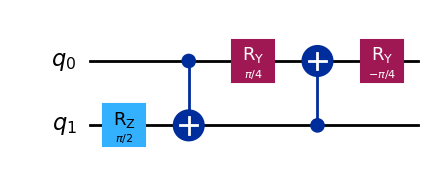

q_a: 4, q_b: 8, for i: 1
Addition Circuit:


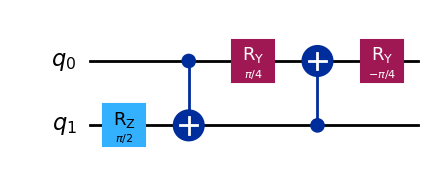

q_a: 5, q_b: 9, for i: 2
Addition Circuit:


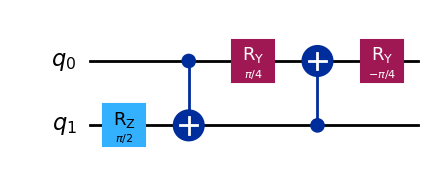

q_a: 6, q_b: 10, for i: 3
Addition Circuit:


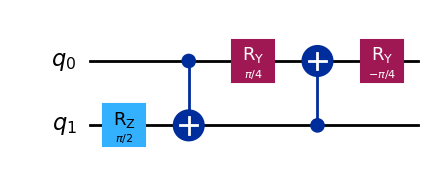

.... PARAMETRIZED CIRCUIT .............., cx-depth=20
Gates count: OrderedDict({'ry': 44, 'cx': 40, 'barrier': 10, 'measure': 7, 'rz': 4, 'h': 3})


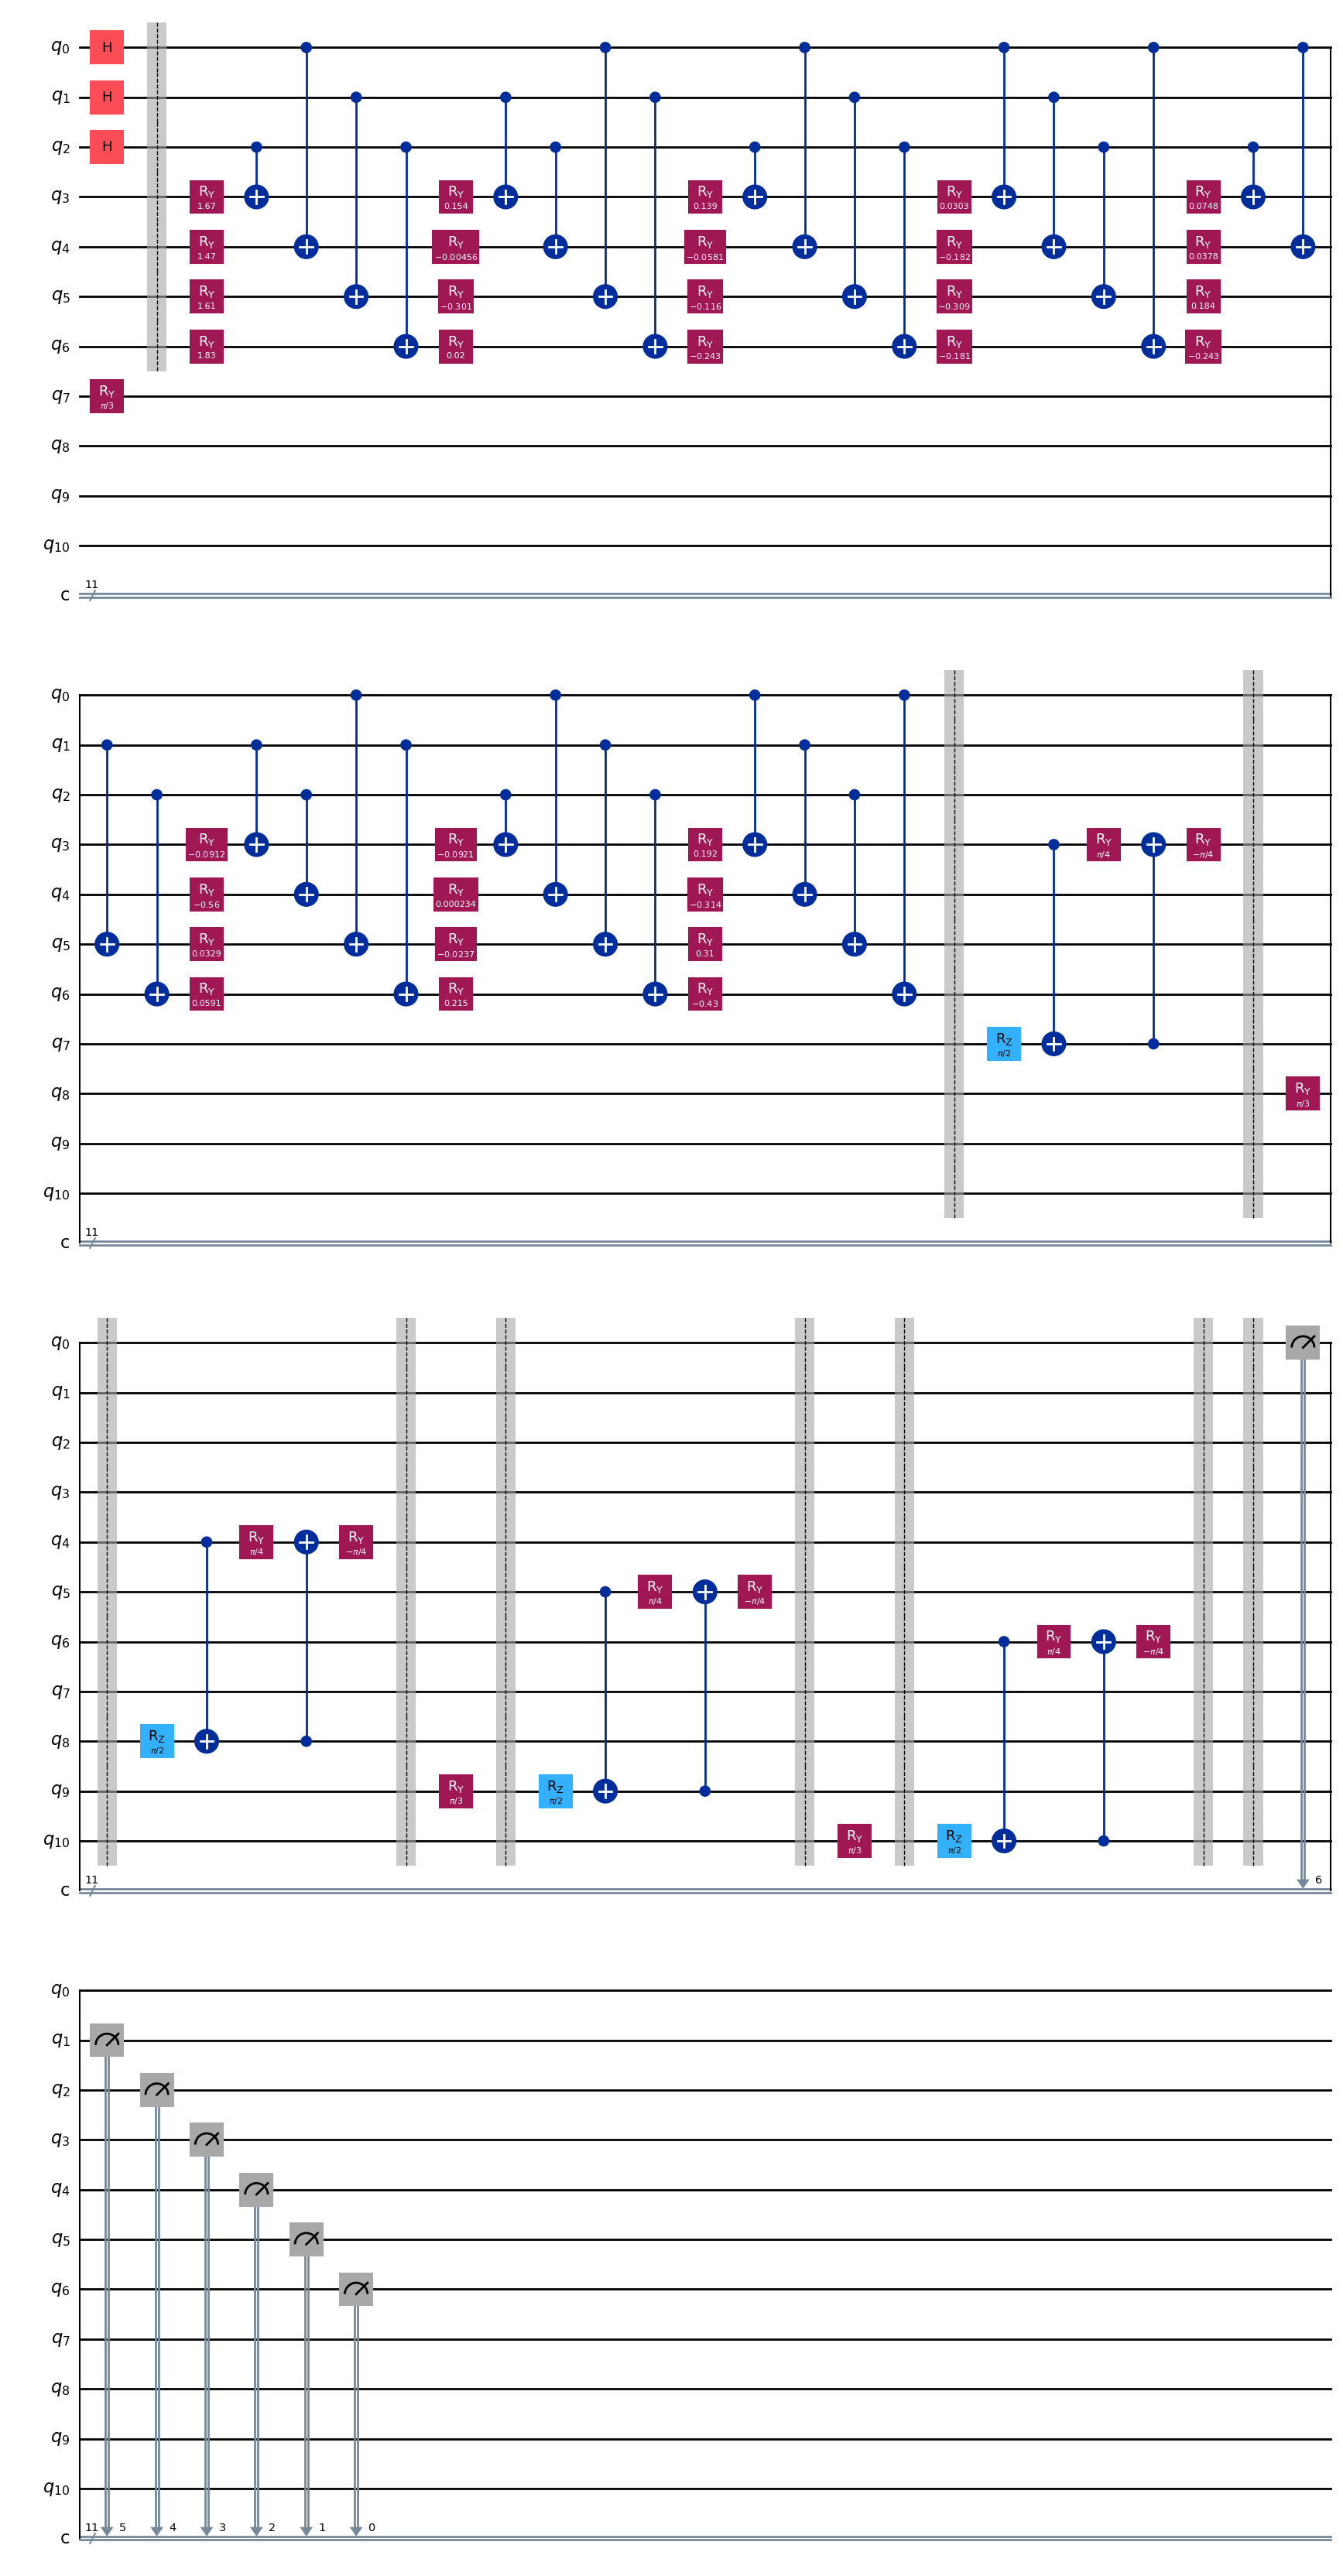

QRFY: nq_addr,nq_data= 3 4  addrBitsL: [4, 5, 6]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.303  std= 0.155  corr=1.00   tilt angle=3.2/deg
Overall 
residuals: mean=-0.303  std=0.155  corr=0.998


Cube original data:
 [[[-0.4865933 ]]

 [[-0.28536846]]

 [[-0.20183036]]

 [[-0.17328327]]

 [[-0.33480247]]

 [[ 0.5733248 ]]

 [[ 0.02909197]]

 [[ 0.06191247]]]
Reconstructed data:
 [[[0.01174706]]

 [[0.11732113]]

 [[0.13341554]]

 [[0.16513761]]

 [[0.09557916]]

 [[0.53886505]]

 [[0.25634766]]

 [[0.28431373]]]
Difference:
 [[[-0.49834036]]

 [[-0.40268959]]

 [[-0.3352459 ]]

 [[-0.33842089]]

 [[-0.43038162]]

 [[ 0.03445976]]

 [[-0.22725569]]

 [[-0.22240125]]]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean=-0.215  std= 0.297  corr=1.00   tilt angle=3.0/deg
Overall 
residuals: mean=-0.215  std=0.297  corr=0.999


Cube original data:
 [[[ 0.92660276]]

 [[-0.33232281]

In [15]:
n_cubes = 4
all_rec_list, all_data_list = test_qcrank_ehands_single_iso_n_data(n_cubes)

-----------------------------Analysis of Original Cube 1 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.486593      | 0.011747       | -0.498340      |
| -0.285368      | 0.117321       | -0.402690      |
| -0.201830      | 0.133416       | -0.335246      |
| -0.173283      | 0.165138       | -0.338421      |
| -0.334802      | 0.095579       | -0.430382      |
| 0.573325       | 0.538865       | 0.034460       |
| 0.029092       | 0.256348       | -0.227256      |
| 0.061912       | 0.284314       | -0.222401      |
| -0.683087      | -0.119407      | -0.563681      |
| -0.652050      | -0.082937      | -0.569113      |
| 0.942293       | 0.729478       | 0.212814       |
| -0.595472      | -0.068553      | -0.526918      |
| 0.162766       | 0.318940       | -0.156174      |
| -0.198304      | 0.180864       | -0.37916

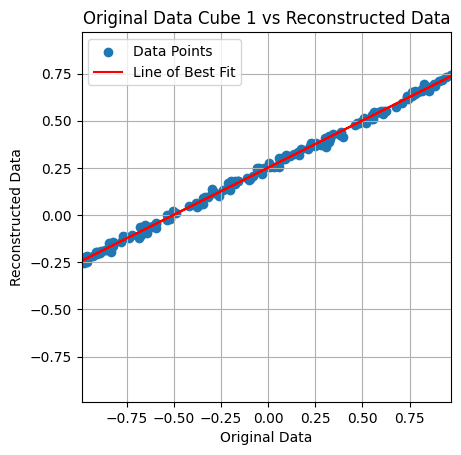

-----------------------------Analysis of Original Cube 2 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.926603       | 0.700075       | 0.226528       |
| -0.332323      | 0.085522       | -0.417844      |
| -0.467223      | -0.001726      | -0.465497      |
| 0.076525       | 0.291647       | -0.215121      |
| -0.058687      | 0.228945       | -0.287632      |
| 0.775768       | 0.628040       | 0.147728       |
| 0.485610       | 0.503418       | -0.017808      |
| -0.805063      | -0.111765      | -0.693298      |
| 0.607216       | 0.512324       | 0.094893       |
| 0.020960       | 0.244300       | -0.223340      |
| 0.289679       | 0.397697       | -0.108018      |
| 0.158686       | 0.338375       | -0.179689      |
| 0.866515       | 0.695289       | 0.171226       |
| -0.178691      | 0.171101       | -0.34979

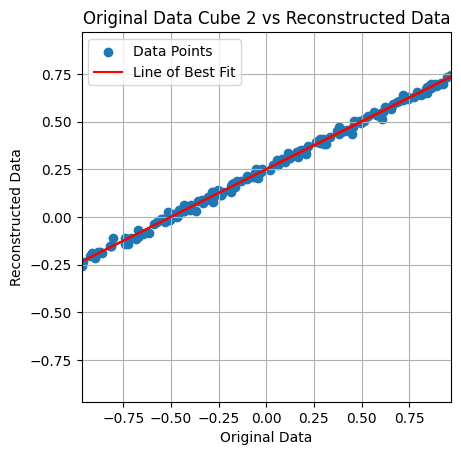

-----------------------------Analysis of Original Cube 3 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.182016       | 0.319170       | -0.137154      |
| 0.928177       | 0.709949       | 0.218228       |
| -0.590911      | -0.043157      | -0.547755      |
| 0.330832       | 0.412844       | -0.082012      |
| -0.232670      | 0.131637       | -0.364308      |
| -0.094365      | 0.202194       | -0.296559      |
| -0.657559      | -0.063965      | -0.593595      |
| -0.343657      | 0.067647       | -0.411304      |
| -0.289660      | 0.104092       | -0.393752      |
| -0.231488      | 0.118016       | -0.349503      |
| -0.255469      | 0.114923       | -0.370392      |
| -0.785470      | -0.145157      | -0.640313      |
| 0.321727       | 0.399902       | -0.078175      |
| -0.063238      | 0.195997       | -0.25923

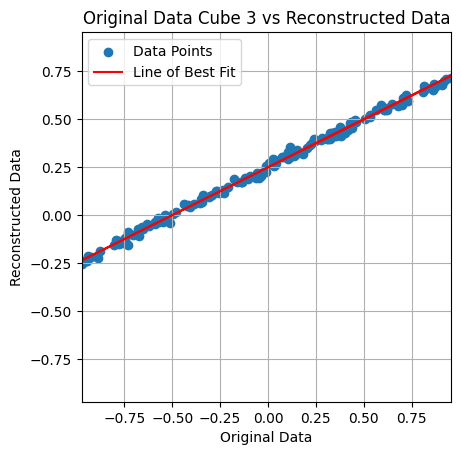

-----------------------------Analysis of Original Cube 4 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.516675       | 0.512122       | 0.004554       |
| 0.602002       | 0.578415       | 0.023587       |
| -0.622890      | -0.068311      | -0.554580      |
| 0.164224       | 0.329310       | -0.165085      |
| -0.253164      | 0.137565       | -0.390729      |
| -0.948927      | -0.216023      | -0.732904      |
| -0.669811      | -0.080566      | -0.589244      |
| -0.497315      | 0.027451       | -0.524765      |
| 0.052469       | 0.289782       | -0.237313      |
| -0.447682      | 0.052368       | -0.500050      |
| 0.851461       | 0.678020       | 0.173441       |
| 0.804758       | 0.670163       | 0.134594       |
| -0.665634      | -0.088322      | -0.577313      |
| -0.000044      | 0.267757       | -0.26780

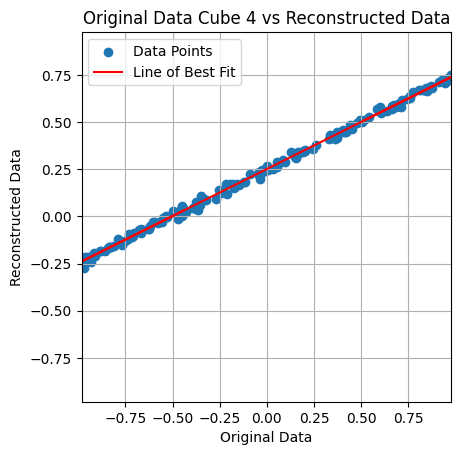

In [19]:
for i in range(n_cubes):
    print(f"-----------------------------Analysis of Original Cube {i + 1} vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Data  | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[i]).flatten(),
                    np.concatenate(all_rec_list[i]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[i]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = f'Original Data Cube {i + 1} vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[i]).flatten(),
                    np.concatenate(all_data_list[i]).flatten(), 
                    title, x_label, y_label, legend)